In [1]:
!pip install opencv-python

Defaulting to user installation because normal site-packages is not writeable


In [ ]:
!pip install fastai

In [75]:
import os
from PIL import Image

train_dir = 'Train'

mask_images = []
non_mask_images = []
classes = ['Mask', 'Non Mask']

for class_name in classes:
    class_path = os.path.join(train_dir, class_name)
    
    if os.path.isdir(class_path):
        for count, image_name in enumerate(os.listdir(class_path), start=1):
            image_path = os.path.join(class_path, image_name)
            try:
                image = Image.open(image_path)
                new_name = f"img{count}{os.path.splitext(image_name)[1]}"
                new_path = os.path.join(class_path, new_name)
                os.rename(image_path, new_path)
                
                if class_name == 'Mask':
                    mask_images.append((image, new_name))
                else:
                    non_mask_images.append((image, new_name))
                    
            except Exception as e:
                print(f"Error loading image {image_path}: {e}")

def create_thumbnails(images, size=(256, 256)):
    for idx in range(len(images)):
        img, name = images[idx]
        img.thumbnail(size)
        images[idx] = (img, name)

create_thumbnails(mask_images)
create_thumbnails(non_mask_images)

if mask_images:
    mask_images[0][0].show()
    print(f"Label: Mask, New Name: {mask_images[0][1]}")

if non_mask_images:
    non_mask_images[0][0].show()
    print(f"Label: Non Mask, New Name: {non_mask_images[0][1]}")


Label: Mask, New Name: img1.jpg
Label: Non Mask, New Name: img1.jpg


In [76]:
from fastai.vision.all import *

In [77]:
for i in range(min(3, len(non_mask_images))):  
    non_mask_images[i][0].show()  
for i in range(min(3, len(non_mask_images))):  
    mask_images[i][0].show()  

In [78]:
from fastai.vision.all import *

# Define your data and labels
path = Path('Train')
dls = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_image_files,
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    get_y=parent_label,
    item_tfms=Resize(256),
    batch_tfms=aug_transforms(size=224)
).dataloaders(path, bs=32)

# Verify the labels
print(dls.vocab)  # This should print ['Mask', 'Non Mask']

# Train the model
learner = vision_learner(dls, resnet34, metrics=accuracy)
learner.fine_tune(1)

['Mask', 'Non Mask']


epoch,train_loss,valid_loss,accuracy,time
0,0.671340,0.464763,0.800000,00:02


epoch,train_loss,valid_loss,accuracy,time
0,0.108489,0.022653,0.983333,00:02


In [79]:
import os
from PIL import Image

test_dir = 'Validation'
test_mask_images = []
test_non_mask_images = []
test_classes = ['Mask', 'Non Mask']

for class_name in test_classes:
    class_path = os.path.join(test_dir, class_name)
    
    if os.path.isdir(class_path):
        for count, image_name in enumerate(os.listdir(class_path), start=1):
            image_path = os.path.join(class_path, image_name)
            try:
                image = Image.open(image_path)
                new_name = f"test_img{count}{os.path.splitext(image_name)[1]}"
                new_path = os.path.join(class_path, new_name)
                os.rename(image_path, new_path)
                
                if class_name == 'Mask':
                    test_mask_images.append((image, new_name))
                else:
                    test_non_mask_images.append((image, new_name))
                    
            except Exception as e:
                print(f"Error loading image {image_path}: {e}")

def create_thumbnails(images, size=(256, 256)):
    for idx in range(len(images)):
        img, name = images[idx]
        img.thumbnail(size)
        images[idx] = (img, name)

create_thumbnails(test_mask_images)
create_thumbnails(test_non_mask_images)

if test_mask_images:
    test_mask_images[0][0].show()
    print(f"Label: Mask, New Name: {test_mask_images[0][1]}")

if test_non_mask_images:
    test_non_mask_images[0][0].show()
    print(f"Label: Non Mask, New Name: {test_non_mask_images[0][1]}")

Error loading image Validation/Mask/.ipynb_checkpoints: [Errno 21] Is a directory: 'Validation/Mask/.ipynb_checkpoints'
Label: Mask, New Name: test_img1.png
Label: Non Mask, New Name: test_img1.jpg


In [80]:
import random

This is a: Mask.
Probability it's a Mask: 0.9990


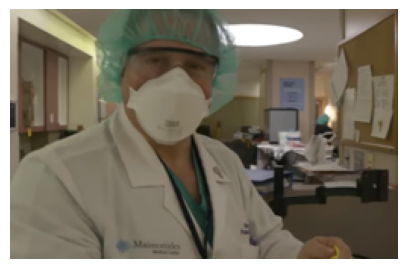

In [91]:
i = random.randint(0,(min(len(test_mask_images),len(test_non_mask_images))))
img = test_mask_images[i][0]
is_mask,_,probs = learner.predict(img)
img.show()
print(f"This is a: {is_mask}.")
print(f"Probability it's a Mask: {probs[0]:.4f}")

This is a: Mask.
Probability it's a Mask: 0.6272


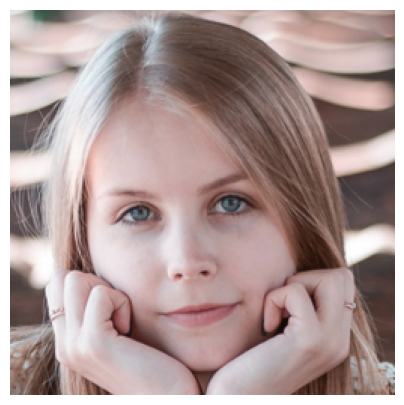

In [111]:
i = random.randint(0,(min(len(test_mask_images),len(test_non_mask_images))))
img2 = test_non_mask_images[i][0]
is_mask,_,probs = learner.predict(img2)
img2.show()
print(f"This is a: {is_mask}.")
print(f"Probability it's a Mask: {probs[0]:.4f}")